In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from PIL import Image
from transformers import DistilBertModel, AutoTokenizer, CLIPVisionModelWithProjection, CLIPProcessor
from peft import PeftModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
import unicodedata

In [ ]:
!pip install --upgrade torchao peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 11.9 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
!unzip -q /content/images_final -d /content/images/

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_DIR = '/content/drive/MyDrive/checkpoints/stage2'
CSV_PATH   = '/content/drive/MyDrive/metadata_stage1_ready.xlsx'
IMAGE_ROOT = '/content/images/images_final'

# ==========================================
# 1. 모델 형태에 맞게 각각 로드하기
# ==========================================
TEXT_MODEL_NAME = 'sentence-transformers/clip-ViT-B-32-multilingual-v1'
VISION_MODEL_NAME = 'openai/clip-vit-base-patch32'

print("⏳ 학습된 가중치를 불러오는 중...")

# 1) Text Encoder: Full Model로 저장되었으므로 일반적인 방식으로 바로 불러옵니다.
text_encoder = DistilBertModel.from_pretrained(os.path.join(SAVE_DIR, "text_lora")).to(device)
text_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)

# 2) Vision Encoder: LoRA로 저장되었으므로 베이스 모델을 부르고 PeftModel로 합칩니다.
base_vision_encoder = CLIPVisionModelWithProjection.from_pretrained(VISION_MODEL_NAME)
vision_encoder = PeftModel.from_pretrained(base_vision_encoder, os.path.join(SAVE_DIR, "vision_lora")).to(device)
processor = CLIPProcessor.from_pretrained(VISION_MODEL_NAME)

print("✅ 두 모델 모두 성공적으로 로드되었습니다!")

⏳ 학습된 가중치를 불러오는 중...


Loading weights:   0%|          | 0/100 [00:01<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/371 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ 두 모델 모두 성공적으로 로드되었습니다!


In [ ]:
#한글 폰트 설치
!apt-get -qq -y install fonts-nanum

Selecting previously unselected package fonts-nanum.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import matplotlib.font_manager as fm

# --- 1. 한글 인코딩 문제 해결을 위한 정규화 함수 ---
def dn(text):
    if pd.isna(text): return ""
    return unicodedata.normalize('NFC', str(text)).strip()

# --- 2. 실제 폴더 안의 파일들을 미리 스캔 (가장 먼저 실행!) ---
print("🔎 이미지 폴더 스캔 중...")
actual_file_map = {dn(f): f for f in os.listdir(IMAGE_ROOT) if not f.startswith('.')}
print(f"✅ 총 {len(actual_file_map)}개의 실제 파일 인식 완료.")

# --- 3. 데이터 로드 (분할 없이 전체 데이터 사용) ---
df = pd.read_excel(CSV_PATH)

_, val_df = train_test_split(df, test_size=0.1, random_state=42)

SCENE_CLASSES = ['바다','산','숲','도시','호수','거리','전통','공원','전망','조형물','카페','온천','전시']
SCENE2IDX     = {s: i for i, s in enumerate(SCENE_CLASSES)}
NUM_CLASSES   = len(SCENE_CLASSES)

BATCH_SIZE = 64 # 전체 데이터를 빠르게 뽑기 위해 배치 사이즈를 늘림

print(f'\n최초 엑셀 데이터: {len(df)}장')

# --- 4. 🚨 전체 데이터(df) 대상 안전한 파일 필터링 ---
safe_rows = []
empty_num = 0

for idx, row in df.iterrows():
    target_id = dn(row['image_id'])
    real_file_name = actual_file_map.get(target_id)

    if real_file_name:
        img_path = os.path.join(IMAGE_ROOT, real_file_name)
        if os.path.exists(img_path):
            safe_rows.append(row)
        else:
            print(f"❌ 누락 파일 발견 (제외됨): {target_id}")
            empty_num += 1
    else:
        print(f"❌ 매핑 실패 (제외됨): {target_id}")
        empty_num += 1

print(f"총 누락/매핑 실패 개수: {empty_num}")

# 전체 검색을 위한 새로운 DataFrame 생성
full_df_safe = pd.DataFrame(safe_rows).reset_index(drop=True)
print(f'✅ 최종 안전한 전체 데이터(검색 DB): {len(full_df_safe)}장')

# --- 5. Dataset 및 DataLoader 정의 ---
class TravelDataset(Dataset):
    def __init__(self, df, image_root, processor, tokenizer, scene2idx):
        self.df         = df.reset_index(drop=True)
        self.image_root = image_root
        self.processor  = processor
        self.tokenizer  = tokenizer
        self.scene2idx  = scene2idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        target_id = dn(row['image_id'])
        real_file_name = actual_file_map.get(target_id)

        if real_file_name is None:
            raise FileNotFoundError(f"❌ 파일 없음: {target_id} (엑셀 행 번호: {idx})")

        img_path = os.path.join(self.image_root, real_file_name)

        try:
            image = Image.open(img_path).convert('RGB')
            pixel_values = self.processor(images=image, return_tensors='pt')['pixel_values'].squeeze(0)
        except Exception as e:
            print(f"❌ 이미지 로드 실패: {img_path}")
            raise e

        enc = self.tokenizer(
            str(row['caption']),
            padding='max_length', max_length=64,
            truncation=True, return_tensors='pt'
        )
        input_ids      = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)
        scene_label = self.scene2idx.get(str(row['scene']), 0)

        return pixel_values, input_ids, attention_mask, scene_label

full_dataset  = TravelDataset(full_df_safe, IMAGE_ROOT, processor, text_tokenizer, SCENE2IDX)
full_loader   = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ==========================================
# 6. Custom Heads 가중치 로드
# ==========================================
class ProjectionHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256)
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

class SceneHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(512, 256),   # net.0
            nn.ReLU(),             # net.1
            nn.Dropout(0.3),       # net.2
            nn.Linear(256, 13)     # net.3
        )
    def forward(self, x):
        return self.net(x)

txt_proj_layer = nn.Linear(768, 512).to(device)
proj_head = ProjectionHead().to(device)
scene_head = SceneHead().to(device)

heads_state = torch.load(os.path.join(SAVE_DIR, "custom_heads.pt"), map_location=device)
txt_proj_layer.load_state_dict(heads_state['txt_proj_layer'])
proj_head.load_state_dict(heads_state['proj_head'])
scene_head.load_state_dict(heads_state['scene_head'])

print("✅ Stage 2 모델 로드 완료! 전체 임베딩 추출을 시작합니다.")

# ==========================================
# 7. 전체 데이터 임베딩 추출 및 지표 확인
# ==========================================
vision_encoder.eval()
proj_head.eval()
full_img_embeddings = []

print("🚀 전체 사진의 특징(Vibe)만 초고속으로 추출하여 DB를 구축합니다...")

with torch.no_grad():
    for batch in full_loader:
        # 오직 사진만 가져옵니다!
        pixel_values = batch[0].to(device)

        # 1. 시각적 특징 추출
        img_feat = vision_encoder(pixel_values=pixel_values).image_embeds

        # 2. 256차원 감성 벡터로 압축
        i_emb = proj_head(img_feat)

        # 3. 리스트에 저장
        full_img_embeddings.append(i_emb.cpu().numpy())

# 리스트를 하나의 Numpy 배열로 합치기
full_img_embeddings = np.concatenate(full_img_embeddings, axis=0)

🔎 이미지 폴더 스캔 중...
✅ 총 4831개의 실제 파일 인식 완료.

최초 엑셀 데이터: 4260장
❌ 매핑 실패 (제외됨): 숨도_5_공공3유형.jpg
❌ 매핑 실패 (제외됨): 숨도_6_공공3유형.jpg
❌ 매핑 실패 (제외됨): 제주동백수목원_5_공공3유형.jpg
❌ 매핑 실패 (제외됨): 김녕_청굴물_1_공공3유형.jpg
❌ 매핑 실패 (제외됨): 나바론하늘길_1_공공3유형.jpg
❌ 매핑 실패 (제외됨): 나바론하늘길_2_공공3유형.jpg
❌ 매핑 실패 (제외됨): 나바론하늘길_3_공공3유형.jpg
❌ 매핑 실패 (제외됨): 서건도_3_공공3유형.jpg
❌ 매핑 실패 (제외됨): 쉬리의언덕_1_공공3유형.jpg
❌ 매핑 실패 (제외됨): 제주특별자치도농업기술원서부농업기술센터_1_공공3유형.jpg
❌ 매핑 실패 (제외됨): 제주특별자치도농업기술원서부농업기술센터_4_공공3유형.jpg
❌ 매핑 실패 (제외됨): 제주특별자치도농업기술원서부농업기술센터_3_공공3유형.jpg
❌ 매핑 실패 (제외됨): 제주동화마을_1_공공3유형.jpg
❌ 매핑 실패 (제외됨): 고살리_숲길_1_공공3유형.jpg
❌ 매핑 실패 (제외됨): 식장산_문화공원(해돋이전망대)_1_공공3유형.jpg
❌ 매핑 실패 (제외됨): 보문산_행복_숲_둘레길_9_공공3유형.jpg
❌ 매핑 실패 (제외됨): 보문산_행복_숲_둘레길_10_공공3유형.jpg
❌ 매핑 실패 (제외됨): 회덕메타세쿼이아길_8_공공3유형.jpg
❌ 매핑 실패 (제외됨): 회덕메타세쿼이아길_2_공공3유형.jpg
❌ 매핑 실패 (제외됨): 명상정원_7_공공3유형.jpg
❌ 매핑 실패 (제외됨): 회덕메타세쿼이아길_4_공공3유형.jpg
❌ 매핑 실패 (제외됨): 보은_서원리_소나무_7_공공3유형.jpg
❌ 매핑 실패 (제외됨): 보은_서원리_소나무_6_공공3유형.jpg
❌ 매핑 실패 (제외됨): 도담정원_3_공공1유형.jpg
❌ 매핑 실패 (제외됨): 괴산_오가리_느티나무_1_공공3유형.jpg
❌ 매핑 실패 (제외됨): 제천_의

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
import numpy as np
import pandas as pd

# 1. 임베딩 저장 (.npy)
np.save('full_img_embeddings.npy', full_img_embeddings)

# 2. 메타데이터 저장 (.csv)
# 검색 인덱스와 행(row) 번호가 일치해야 하므로 반드시 인덱스를 포함하여 저장
full_df_safe.to_csv('metadata.csv', index=False, encoding='utf-8-sig')

# 3. 매핑 테이블 및 설정값 저장 (.pkl)
config = {
    'SCENE2IDX': SCENE2IDX,
    'IDX2SCENE': {v: k for k, v in SCENE2IDX.items()},
    'actual_file_map': actual_file_map,
    'embedding_dim': 256
}
import pickle
with open('config.pkl', 'wb') as f:
    pickle.dump(config, f)

print("✅ 모든 파일 저장 완료! (full_img_embeddings.npy, metadata.csv, config.pkl)")

✅ 모든 파일 저장 완료! (full_img_embeddings.npy, metadata.csv, config.pkl)


In [ ]:
# 안전한 파일 필터링
safe_val_rows = []
empty_val_num = 0

for idx, row in val_df.iterrows():
    target_id = dn(row['image_id'])
    real_file_name = actual_file_map.get(target_id)

    if real_file_name and os.path.exists(os.path.join(IMAGE_ROOT, real_file_name)):
        safe_val_rows.append(row)
    else:
        empty_val_num += 1

val_df_safe = pd.DataFrame(safe_val_rows).reset_index(drop=True)
print(f"✅ 복원된 평가용 데이터: {len(val_df_safe)}장 (누락: {empty_val_num}장)")

# 로더 생성 (채점용이므로 batch_size는 작아도 상관없음)
val_dataset = TravelDataset(val_df_safe, IMAGE_ROOT, processor, text_tokenizer, SCENE2IDX)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# ==========================================
# 정량적 평가 (Loss, Acc, Silhouette) 진행
# ==========================================
text_encoder.eval(); vision_encoder.eval()
txt_proj_layer.eval(); proj_head.eval(); scene_head.eval()

val_loss = 0.0
correct_scene = 0
total_samples = 0

val_img_embeddings = []
val_scene_labels = []

with torch.no_grad():
    for batch in val_loader:
        pixel_values, input_ids, attention_mask, scene_labels = [b.to(device) for b in batch]

        # 모델 통과
        img_feat = vision_encoder(pixel_values=pixel_values).image_embeds
        txt_out = text_encoder(input_ids=input_ids, attention_mask=attention_mask)[0][:, 0, :]
        txt_feat = txt_proj_layer(txt_out)

        i_emb = proj_head(img_feat)
        t_emb = proj_head(txt_feat)

        # Loss 계산
        logits = i_emb @ t_emb.T * (1.0 / 0.07)
        targets = torch.arange(pixel_values.size(0)).to(device)
        loss_clip = (F.cross_entropy(logits, targets) + F.cross_entropy(logits.T, targets)) / 2

        scene_logits = scene_head(img_feat)
        loss_ce = F.cross_entropy(scene_logits, scene_labels)

        loss = loss_clip + loss_ce
        val_loss += loss.item()

        # Acc 계산
        preds = torch.argmax(scene_logits, dim=1)
        correct_scene += (preds == scene_labels).sum().item()
        total_samples += scene_labels.size(0)

        # 실루엣 점수를 위한 저장
        val_img_embeddings.append(i_emb.cpu().numpy())
        val_scene_labels.append(scene_labels.cpu().numpy())

# 최종 계산
avg_val_loss = val_loss / len(val_loader)
val_scene_acc = (correct_scene / total_samples) * 100

val_img_embeddings = np.concatenate(val_img_embeddings, axis=0)
val_scene_labels = np.concatenate(val_scene_labels, axis=0)

val_sil_score = silhouette_score(val_img_embeddings, val_scene_labels, metric='cosine')

print("\n" + "🎓"*20)
print("🏆 정량적 평가 결과 (Test 기준)")
print(f"1. Validation Loss: {avg_val_loss:.4f} (낮을수록 교차 모달 학습이 잘 됨)")
print(f"2. Scene Classification Acc: {val_scene_acc:.2f}% (기초 시각 분류 능력)")
print(f"3. Silhouette Score: {val_sil_score:.4f} (감성 벡터 군집화 능력)")
print("🎓"*20)

✅ 복원된 평가용 데이터: 418장 (누락: 8장)

🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓
🏆 정량적 평가 결과 (Test 기준)
1. Validation Loss: 2.1843 (낮을수록 교차 모달 학습이 잘 됨)
2. Scene Classification Acc: 73.92% (기초 시각 분류 능력)
3. Silhouette Score: 0.0690 (감성 벡터 군집화 능력)
🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓🎓


In [ ]:
import matplotlib.font_manager as fm

# ==========================================
# 8. 정성적 평가 (Qualitative Test) - 시각화
# ==========================================
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fontprop = fm.FontProperties(fname=font_path, size=12)

def qualitative_test(query_text, top_k=3):
    print(f"\n🔎 검색어: '{query_text}'")
    with torch.no_grad():
        enc = text_tokenizer(query_text, return_tensors='pt', padding=True, truncation=True)
        txt_out = text_encoder(input_ids=enc['input_ids'].to(device),
                               attention_mask=enc['attention_mask'].to(device))[0][:, 0, :]
        txt_feat = txt_proj_layer(txt_out)
        t_emb = proj_head(txt_feat)

        similarities = (full_img_embeddings @ t_emb.cpu().numpy().T).squeeze()
        top_indices = similarities.argsort()[-top_k:][::-1]

    fig, axes = plt.subplots(1, top_k, figsize=(5 * top_k, 5))
    if top_k == 1: axes = [axes]

    for i, idx in enumerate(top_indices):
        row = full_df_safe.iloc[idx]
        target_id = dn(row['image_id'])

        real_file_name = actual_file_map.get(target_id, target_id)
        img_path = os.path.join(IMAGE_ROOT, real_file_name)

        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            title_text = f"Top {i+1} (Score: {similarities[idx]:.3f})\n{row.get('scene', 'N/A')}"
            axes[i].set_title(title_text, fontproperties=fontprop)
            axes[i].axis('off')
        except Exception as e:
            # 🚨 에러 시 출력할 변수 스코프 문제 해결
            title_text = f"이미지 로드 실패\n{real_file_name}"
            axes[i].set_title(title_text, fontproperties=fontprop)
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

def search_by_image(query_image_path, top_k=3):
    print(f"\n🔍 [이미지 검색 시작] 입력된 사진의 분위기를 분석 중입니다...")

    # 1. 쿼리 이미지 로드 및 화면에 표시
    try:
        query_img = Image.open(query_image_path).convert('RGB')
    except Exception as e:
        print(f"❌ 쿼리 이미지를 불러올 수 없습니다: {query_image_path}")
        return

    # 2. 쿼리 이미지를 모델이 이해할 수 있게 전처리
    pixel_values = processor(images=query_img, return_tensors='pt')['pixel_values'].to(device)

    # 3. 이미지 뇌(Vision Encoder)를 통해 256차원 특징 벡터(Vibe) 추출!
    with torch.no_grad():
        img_feat = vision_encoder(pixel_values=pixel_values).image_embeds
        q_emb = proj_head(img_feat).cpu().numpy() # (1, 256) 크기

    # 4. 전체 DB(400여 장)와 코사인 유사도 계산
    # q_emb와 all_img_embeddings(DB)를 내적하여 유사도 도출
    similarities = (full_img_embeddings @ q_emb.T).squeeze()

    # 5. 자기 자신(똑같은 사진)이 검색될 수 있으니, 유사도가 0.99 이상인 것은 제외
    # (새로운 외부 사진을 넣을 땐 상관없지만, DB 안의 사진을 테스트용으로 쓸 때를 대비함)
    similarities[similarities > 0.99] = -1.0

    # 6. 유사도 Top-K 추출
    top_indices = similarities.argsort()[-top_k:][::-1]

    # ==========================================
    # 🎨 결과 시각화
    # ==========================================
    fig, axes = plt.subplots(1, top_k + 1, figsize=(5 * (top_k + 1), 5))

    # [왼쪽 끝] 사용자가 입력한 쿼리 이미지 출력
    axes[0].imshow(query_img)
    axes[0].set_title("📥 [검색한 사진]\n(사용자 입력)", fontproperties=fontprop, color='blue', weight='bold')
    axes[0].axis('off')

    # [오른쪽] AI가 추천해준 유사한 이미지들 출력
    for i, idx in enumerate(top_indices):
        row = full_df_safe.iloc[idx]
        target_id = dn(row['image_id'])
        real_file_name = actual_file_map.get(target_id, target_id)
        img_path = os.path.join(IMAGE_ROOT, real_file_name)

        ax = axes[i + 1]
        try:
            res_img = Image.open(img_path)
            ax.imshow(res_img)
            title_text = f"추천 {i+1}위 (일치율: {similarities[idx]*100:.1f}%)\n{row.get('scene', 'N/A')}"
            ax.set_title(title_text, fontproperties=fontprop)
            ax.axis('off')
        except:
            ax.set_title("이미지 로드 실패", fontproperties=fontprop)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# 🚀 실행 테스트
# ==========================================


🔎 검색어: '조용하게 힐링이 가능한 곳'


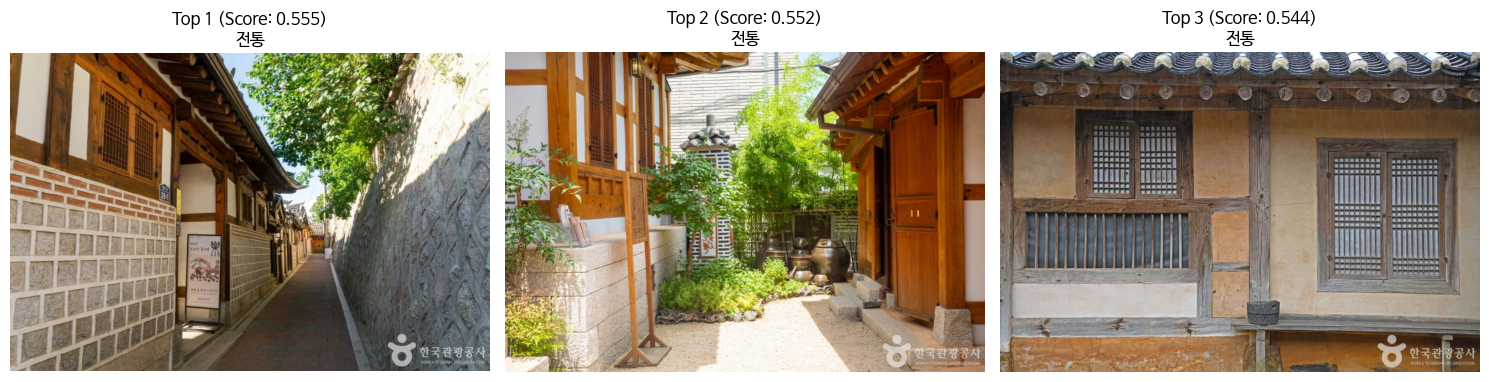


🔎 검색어: '파도 소리가 들리는 청량한 바다'


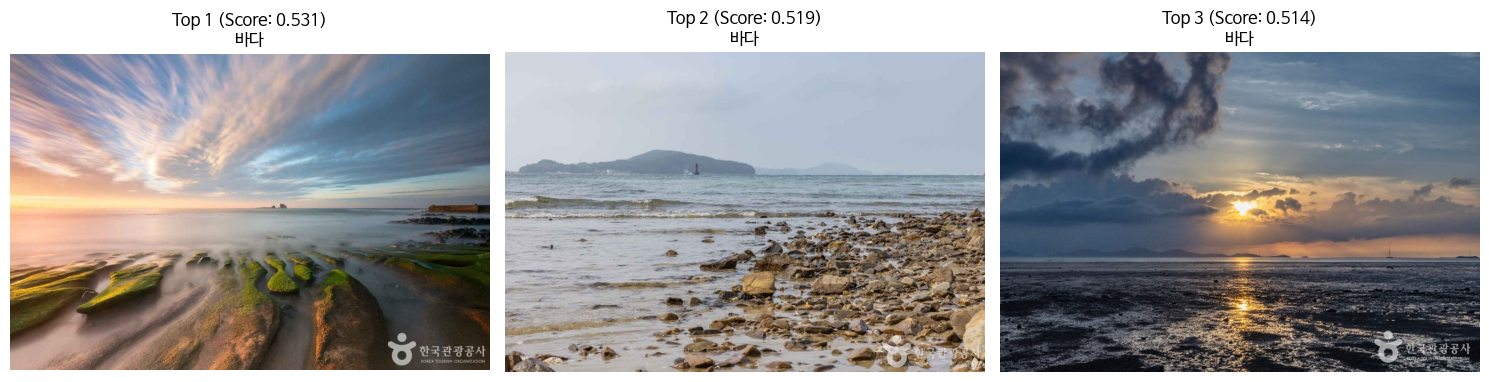


🔍 [이미지 검색 시작] 입력된 사진의 분위기를 분석 중입니다...


/tmp/ipykernel_18863/4088241404.py:103: UserWarning: Glyph 128229 (\N{INBOX TRAY}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128229 (\N{INBOX TRAY}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


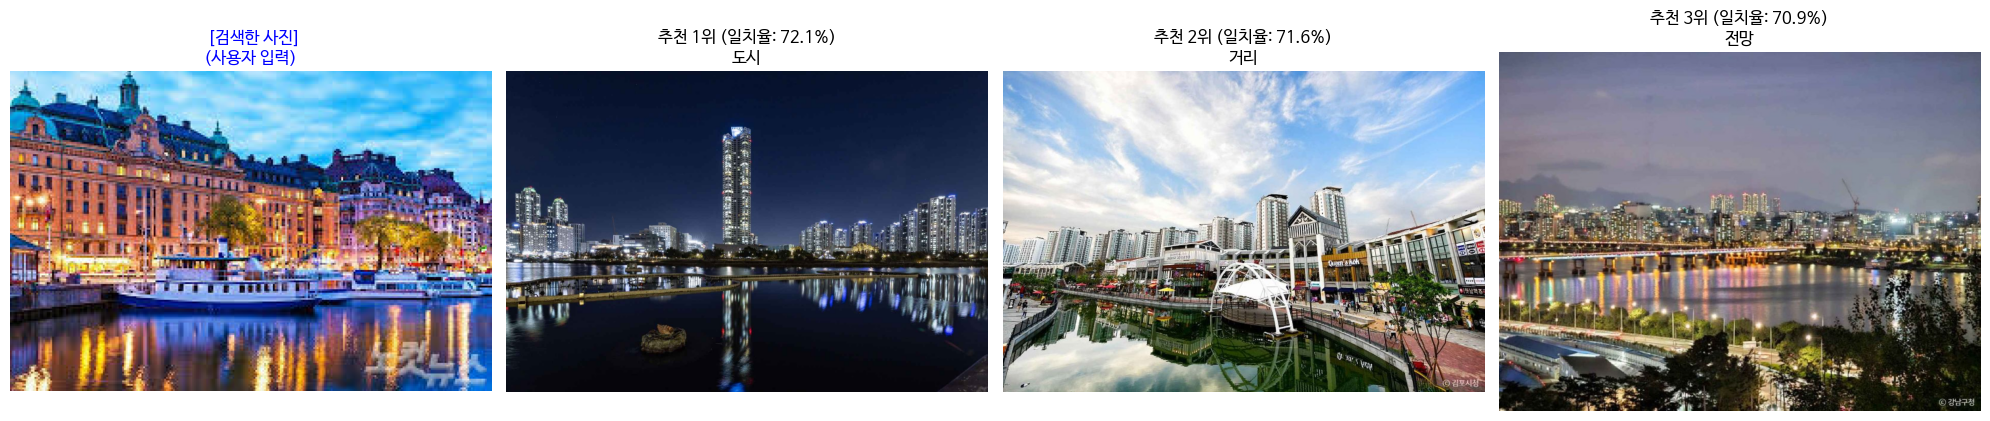


🔍 [이미지 검색 시작] 입력된 사진의 분위기를 분석 중입니다...


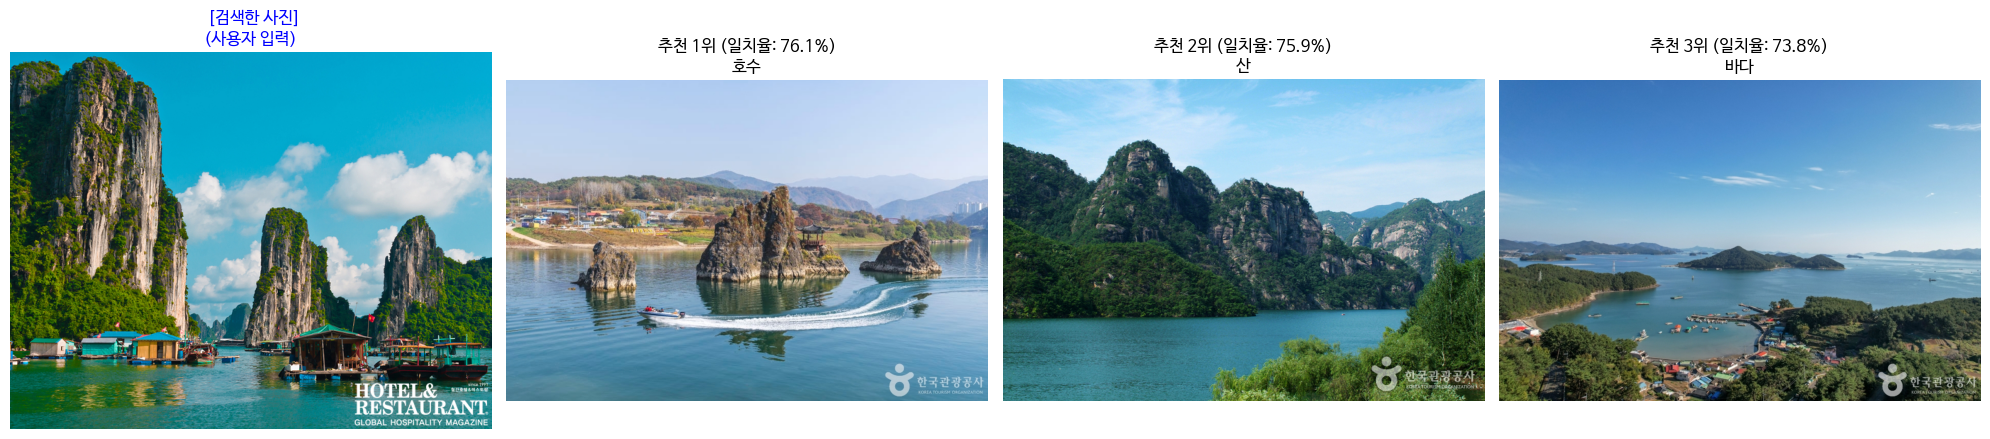

In [ ]:
# 최종 결과물 테스트!
qualitative_test("조용하게 힐링이 가능한 곳", top_k=3)
qualitative_test("파도 소리가 들리는 청량한 바다", top_k=3)

test_target_id = dn(val_df_safe.iloc[0]['image_id'])
test_real_name = actual_file_map.get(test_target_id, test_target_id)
test_image_path = os.path.join(IMAGE_ROOT, test_real_name)

search_by_image("/content/images1.jpg", top_k=3)
search_by_image("/content/images2.jpg", top_k=3)
